# Fine tuning of FL Models

In [11]:
from enums.Participant import NurseParticipant

participant = NurseParticipant.n_F5

In [12]:
import pandas as pd

df = pd.read_pickle(f"../../../datasets/nurse/paper/{participant}.pkl")

In [13]:
from sklearn.model_selection import train_test_split

x = df.drop(columns=["Label", "Participant"])
y = df["Label"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, shuffle=True, stratify=y)

In [14]:
import joblib

model = joblib.load(f"../../../results/bfh_server/federated/models/3ad9ccd1ad3714636bb77a2b618f5fcfed3e96bc27d7ea8f686404eb9fff5bc1_run_index_0_model.pkl")

In [15]:
from keras.src.optimizers import Adam

# Compile the model with a lower learning rate
model.compile(
    optimizer=Adam(learning_rate=0.0001),  # Use a lower learning rate for fine-tuning
    loss='binary_crossentropy',  # Use the same loss function as in original training
    metrics=['accuracy']
)

# Fine-tune the model
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9633 - loss: 3.0246 - val_accuracy: 0.9946 - val_loss: 0.1275
Epoch 2/10
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9895 - loss: 0.3432 - val_accuracy: 0.9963 - val_loss: 0.1040
Epoch 3/10
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9944 - loss: 0.1962 - val_accuracy: 0.9978 - val_loss: 0.0808
Epoch 4/10
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9946 - loss: 0.2089 - val_accuracy: 0.9978 - val_loss: 0.0453
Epoch 5/10
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9966 - loss: 0.0651 - val_accuracy: 0.9983 - val_loss: 0.0201
Epoch 6/10
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9966 - loss: 0.0532 - val_accuracy: 0.9971 - val_loss: 0.0335
Epoch 7/10
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9966 - loss: 0.0462 - val_accuracy: 0.9950 - val_loss: 0.0504
Epoch 8/10
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9972 - loss: 0.028

3338/3338 ━━━━━━━━━━━━━━━━━━━━ 1s 326us/step
F1 score: 0.9993


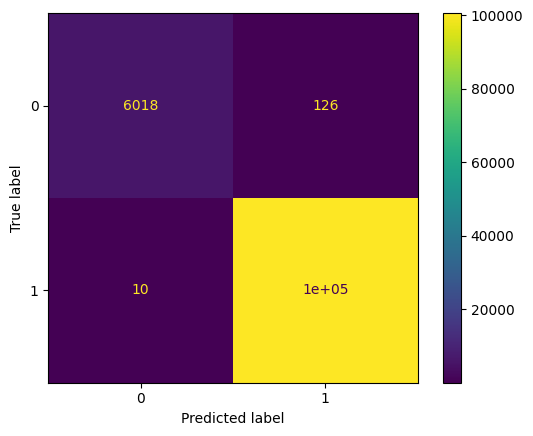

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, confusion_matrix

y_pred = model.predict(x_test)
# Convert predictions to binary labels
y_pred = (y_pred > 0.5).astype(int)
f1 = f1_score(y_test, y_pred)
print(f"F1 score: {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot()
plt.show()